# Semana 8 · Regresión Logística y modelos de clasificación
## CADI Introducción A Machine Learning · Machine Learning Supervisado
**Ruby Dayana Cárdenas Gómez** · Universidad de Cundinamarca · Octubre 2026


En este cuaderno implemento seis algoritmos de clasificación supervisada con Scikit-Learn:
Regresión Logística, Árbol de Decisión, Random Forest, SVM, KNN y Naive Bayes.
Uso el dataset de cáncer de mama de Wisconsin (incluido en Scikit-Learn): 569 pacientes, 30 características medidas de un tumor y una etiqueta que dice si es maligno (0) o benigno (1).
Al final comparo los modelos con precisión, recall, F1 y matriz de confusión.

## 0. Librerías

In [1]:
import numpy as np # números y matrices
import pandas as pd # tablas de datos
import matplotlib.pyplot as plt # gráficas
import seaborn as sns  # matriz de confusión

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
import sklearn
print("Scikit-Learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Scikit-Learn: 1.6.1
Pandas: 2.2.3
NumPy: 2.1.3


## 1. Cargar y explorar los datos
El dataset ya viene etiquetado, así que es un problema de **aprendizaje supervisado** de clasificación binaria.

In [2]:
datos = load_breast_cancer()
X = pd.DataFrame(datos.data, columns=datos.feature_names)   # las 30 características (entradas)
y = pd.Series(datos.target, name="diagnostico") # la etiqueta (salida): 0 = maligno, 1 = benigno

print("Forma de X (filas, columnas):", X.shape)
print("Clases:", {i: str(n) for i, n in enumerate(datos.target_names)})
print("Cantidad por clase:\n", y.value_counts().rename({0: "maligno (0)", 1: "benigno (1)"}))
X.head()

Forma de X (filas, columnas): (569, 30)
Clases: {0: 'malignant', 1: 'benign'}
Cantidad por clase:
 diagnostico
benigno (1)    357
maligno (0)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


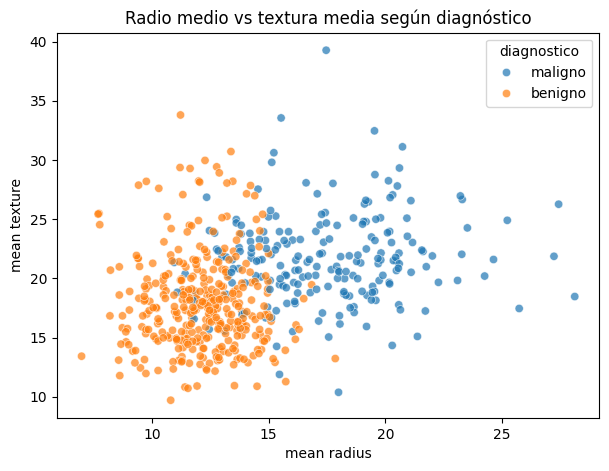

In [3]:
# Veo cómo se distribuyen dos características según el diagnóstico
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X["mean radius"], y=X["mean texture"], hue=y.map({0: "maligno", 1: "benigno"}), alpha=0.7)
plt.title("Radio medio vs textura media según diagnóstico")
plt.show()

## 2. Dividir en entrenamiento y prueba y escalar
Entreno con el 70 % de los datos y guardo el 30 % para evaluar con datos que el modelo nunca vio. Escalo las características porque SVM, KNN y la regresión logística son sensibles a la escala.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)   # aprende la escala con entrenamiento
X_test_esc = escalador.transform(X_test) # y la aplica a prueba

print("Entrenamiento:", X_train.shape[0], "pacientes")
print("Prueba:", X_test.shape[0], "pacientes")

Entrenamiento: 398 pacientes
Prueba: 171 pacientes


## 3. Regresión Logística
Aunque se llama *regresión*, sirve para clasificar: calcula la probabilidad de que un caso sea de la clase 1 usando la función sigmoide y decide con un umbral de 0,5.

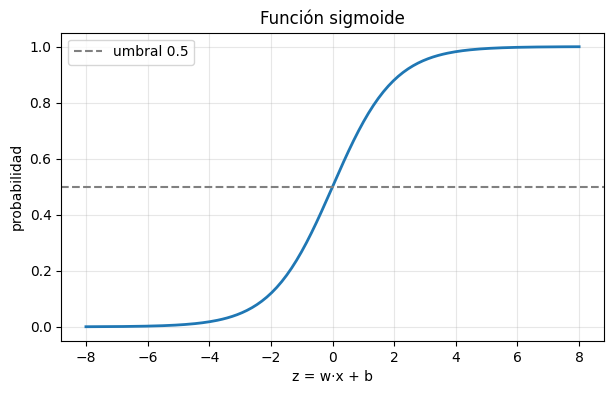

In [5]:
# 3.1 La función sigmoide: convierte cualquier número en una probabilidad entre 0 y 1
z = np.linspace(-8, 8, 200)
sigmoide = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoide, linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", label="umbral 0.5")
plt.title("Función sigmoide")
plt.xlabel("z = w·x + b"); plt.ylabel("probabilidad")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Coeficiente w: -1.027
Intercepto b: 15.116
Exactitud con una sola variable: 0.86


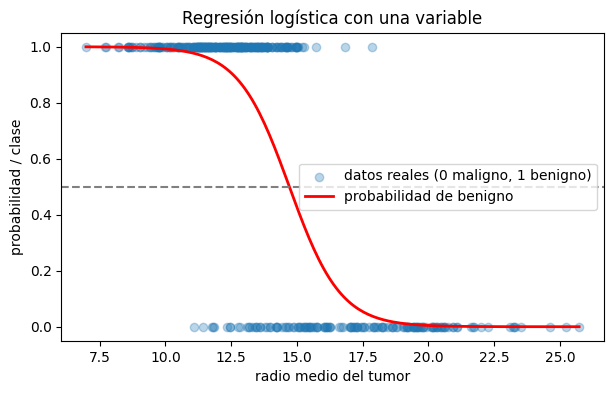

In [6]:
# 3.2 Ejercicio sencillo: regresión logística con UNA sola característica (radio medio)
x1_train = X_train[["mean radius"]].values
x1_test = X_test[["mean radius"]].values

log_simple = LogisticRegression()
log_simple.fit(x1_train, y_train)

print("Coeficiente w:", log_simple.coef_[0][0].round(3))
print("Intercepto b:", log_simple.intercept_[0].round(3))
print("Exactitud con una sola variable:", round(accuracy_score(y_test, log_simple.predict(x1_test)), 3))

# Dibujo la curva de probabilidad sobre los datos
rango = np.linspace(x1_train.min(), x1_train.max(), 200).reshape(-1, 1)
plt.figure(figsize=(7, 4))
plt.scatter(x1_train, y_train, alpha=0.3, label="datos reales (0 maligno, 1 benigno)")
plt.plot(rango, log_simple.predict_proba(rango)[:, 1], color="red", linewidth=2, label="probabilidad de benigno")
plt.axhline(0.5, color="gray", linestyle="--")
plt.xlabel("radio medio del tumor"); plt.ylabel("probabilidad / clase")
plt.title("Regresión logística con una variable")
plt.legend(); plt.show()

Exactitud: 0.9883
Precisión: 0.9907
Recall: 0.9907
F1: 0.9907

              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        64
     benigno       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



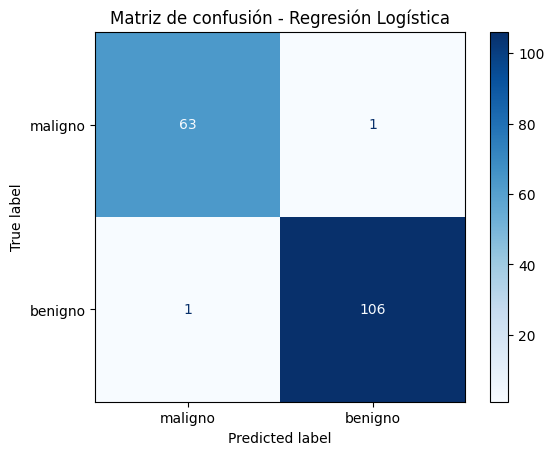

In [7]:
# 3.3 Regresión logística con las 30 características
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_esc, y_train)
pred_log = log_reg.predict(X_test_esc)

print("Exactitud:", round(accuracy_score(y_test, pred_log), 4))
print("Precisión:", round(precision_score(y_test, pred_log), 4))
print("Recall:", round(recall_score(y_test, pred_log), 4))
print("F1:", round(f1_score(y_test, pred_log), 4))
print()
print(classification_report(y_test, pred_log, target_names=["maligno", "benigno"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_log), display_labels=["maligno", "benigno"]).plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

## 4. Modelos de clasificación
Para no repetir código, defino una función que entrena un modelo, calcula las métricas y dibuja su matriz de confusión.

In [8]:
resultados = {}   # aquí guardo las métricas de cada modelo para compararlos al final

def evaluar(nombre, modelo, Xtr, Xte):
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    metricas = {
        "Exactitud": accuracy_score(y_test, pred),
        "Precisión": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }
    resultados[nombre] = metricas
    print(f"=== {nombre} ===")
    for k, v in metricas.items():
        print(f"{k}: {v:.4f}")
    print()
    print(classification_report(y_test, pred, target_names=["maligno", "benigno"]))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["maligno", "benigno"]).plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()
    return modelo

# Guardo también la regresión logística en la tabla de resultados
resultados["Regresión Logística"] = {
    "Exactitud": accuracy_score(y_test, pred_log), "Precisión": precision_score(y_test, pred_log),
    "Recall": recall_score(y_test, pred_log), "F1": f1_score(y_test, pred_log)}
print("Función lista.")

Función lista.


### 4.1 Árbol de decisión (Decision Tree)
Toma decisiones en cascada tipo "si el radio es mayor a X, entonces...". Es fácil de interpretar. No necesita escalado.

=== Árbol de Decisión ===
Exactitud: 0.9240
Precisión: 0.9352
Recall: 0.9439
F1: 0.9395

              precision    recall  f1-score   support

     maligno       0.90      0.89      0.90        64
     benigno       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



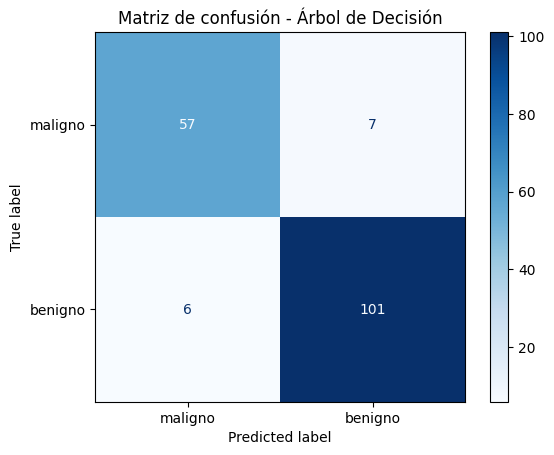

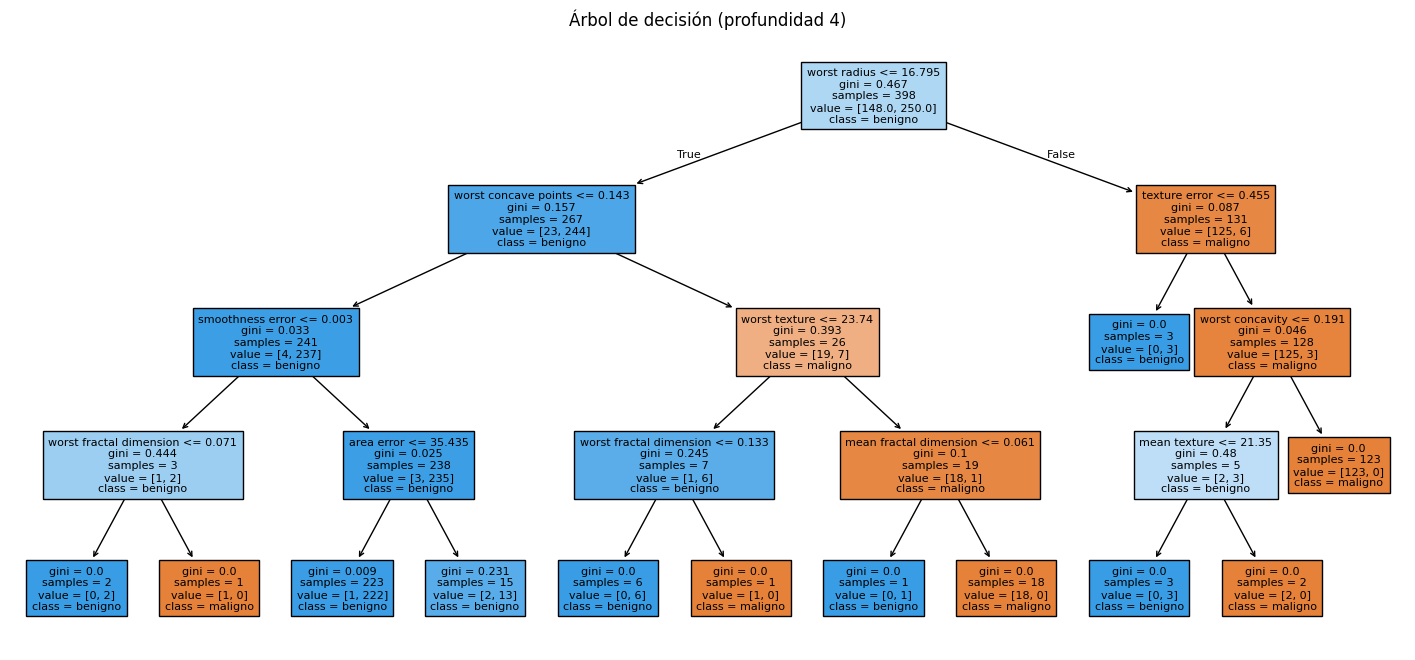

In [9]:
arbol = evaluar("Árbol de Decisión", DecisionTreeClassifier(max_depth=4, random_state=42), X_train, X_test)

# Dibujo el árbol para ver las reglas que aprendió
plt.figure(figsize=(18, 8))
plot_tree(arbol, feature_names=X.columns, class_names=["maligno", "benigno"], filled=True, fontsize=8)
plt.title("Árbol de decisión (profundidad 4)")
plt.show()

### 4.2 Random Forest
Combina muchos árboles entrenados con muestras distintas y vota. Suele ser más preciso y estable que un solo árbol.

=== Random Forest ===
Exactitud: 0.9415
Precisión: 0.9450
Recall: 0.9626
F1: 0.9537

              precision    recall  f1-score   support

     maligno       0.94      0.91      0.92        64
     benigno       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



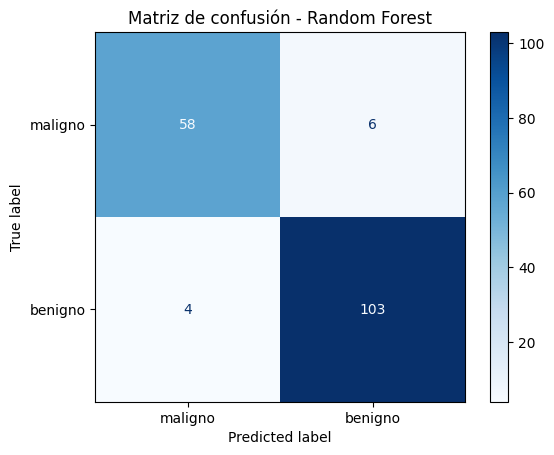

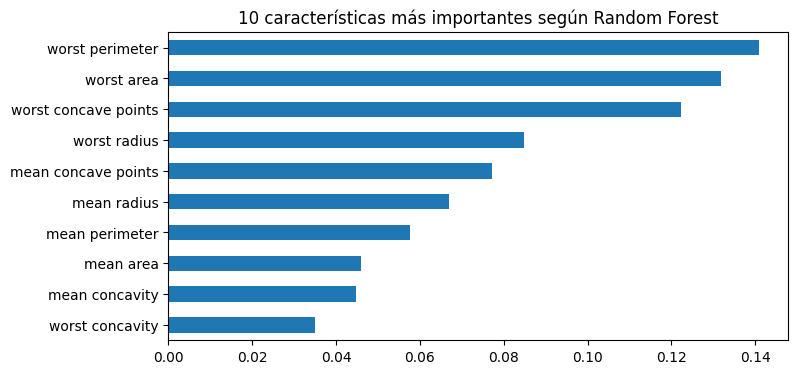

In [10]:
bosque = evaluar("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42), X_train, X_test)

# ¿Qué características importan más para el bosque?
importancias = pd.Series(bosque.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 4))
importancias.sort_values().plot(kind="barh")
plt.title("10 características más importantes según Random Forest")
plt.show()

### 4.3 Máquina de vectores de soporte (SVM)
Busca la frontera que separa las dos clases con el mayor margen posible. Necesita datos escalados.

=== SVM ===
Exactitud: 0.9766
Precisión: 0.9813
Recall: 0.9813
F1: 0.9813

              precision    recall  f1-score   support

     maligno       0.97      0.97      0.97        64
     benigno       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



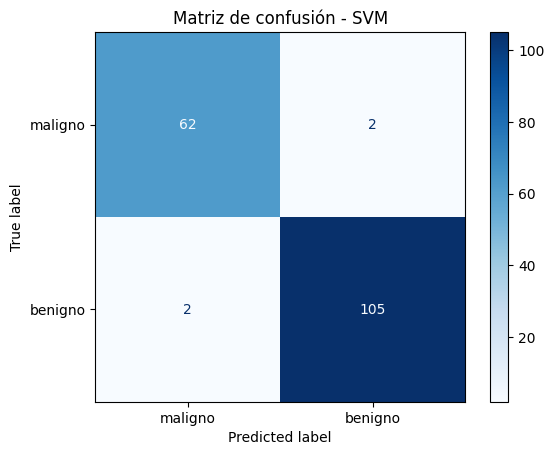

In [11]:
svm = evaluar("SVM", SVC(kernel="rbf", C=1.0, random_state=42), X_train_esc, X_test_esc)

### 4.4 K vecinos más cercanos (KNN)
Clasifica un paciente nuevo mirando a los k pacientes más parecidos. Pruebo varios k para escoger el mejor.

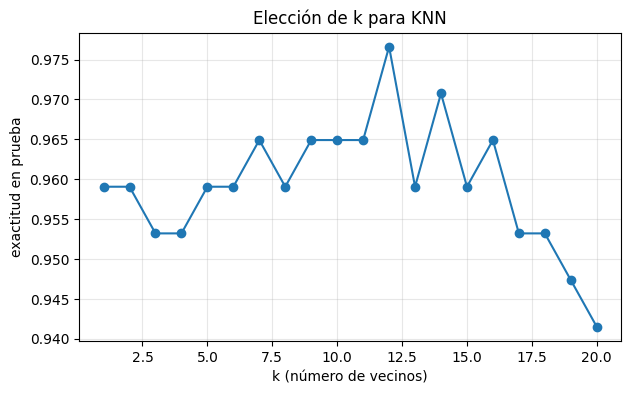

Mejor k: 12
=== KNN ===
Exactitud: 0.9766
Precisión: 0.9640
Recall: 1.0000
F1: 0.9817

              precision    recall  f1-score   support

     maligno       1.00      0.94      0.97        64
     benigno       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



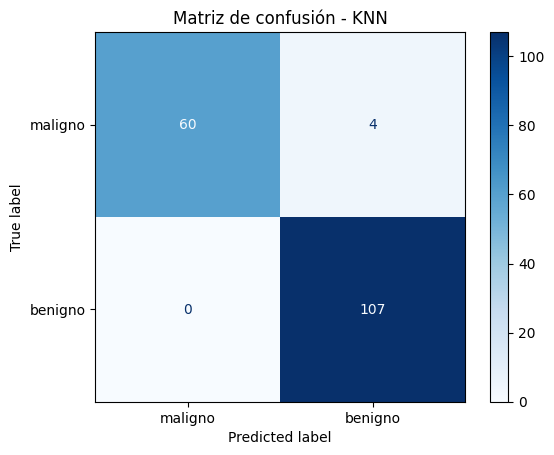

In [12]:
# Pruebo distintos valores de k
exactitudes = []
for k in range(1, 21):
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_train_esc, y_train)
    exactitudes.append(accuracy_score(y_test, knn_k.predict(X_test_esc)))

mejor_k = int(np.argmax(exactitudes)) + 1
plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), exactitudes, marker="o")
plt.xlabel("k (número de vecinos)"); plt.ylabel("exactitud en prueba")
plt.title("Elección de k para KNN"); plt.grid(alpha=0.3)
plt.show()
print("Mejor k:", mejor_k)

knn = evaluar("KNN", KNeighborsClassifier(n_neighbors=mejor_k), X_train_esc, X_test_esc)

### 4.5 Naive Bayes
Usa el teorema de Bayes suponiendo que las características son independientes entre sí. Es muy rápido y no tiene casi parámetros.

=== Naive Bayes ===
Exactitud: 0.9474
Precisión: 0.9375
Recall: 0.9813
F1: 0.9589

              precision    recall  f1-score   support

     maligno       0.97      0.89      0.93        64
     benigno       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



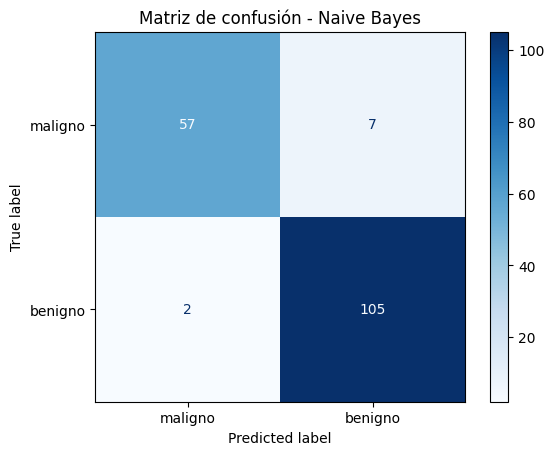

In [13]:
nb = evaluar("Naive Bayes", GaussianNB(), X_train, X_test)

## 5. Comparación de todos los modelos

                     Exactitud  Precisión  Recall      F1
Regresión Logística     0.9883     0.9907  0.9907  0.9907
KNN                     0.9766     0.9640  1.0000  0.9817
SVM                     0.9766     0.9813  0.9813  0.9813
Naive Bayes             0.9474     0.9375  0.9813  0.9589
Random Forest           0.9415     0.9450  0.9626  0.9537
Árbol de Decisión       0.9240     0.9352  0.9439  0.9395


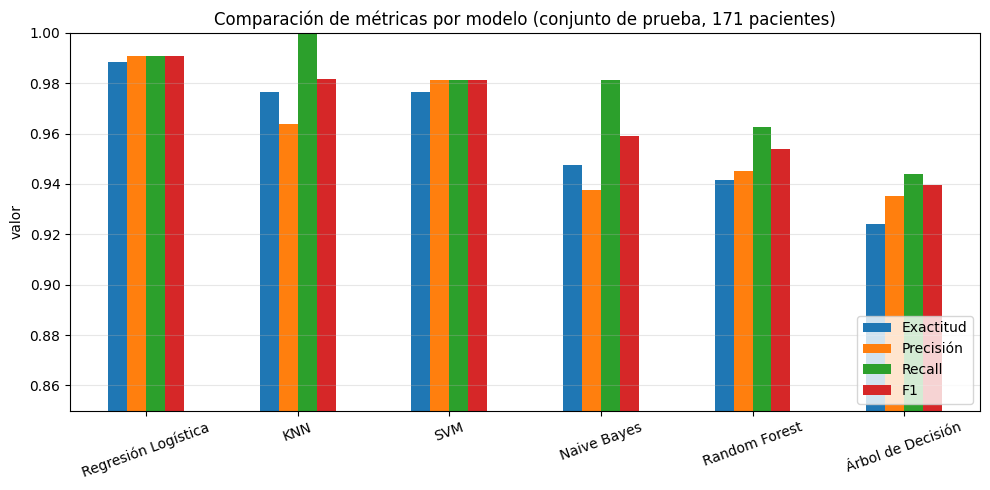

In [14]:
tabla = pd.DataFrame(resultados).T.round(4)
tabla = tabla.sort_values("F1", ascending=False)
print(tabla)

tabla.plot(kind="bar", figsize=(10, 5), ylim=(0.85, 1.0))
plt.title("Comparación de métricas por modelo (conjunto de prueba, 171 pacientes)")
plt.ylabel("valor"); plt.xticks(rotation=20); plt.legend(loc="lower right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Conclusiones del cuaderno
*(Se completan en el informe con los valores obtenidos.)*

- Todos los modelos superan el 90 % de exactitud: el dataset está bien etiquetado y las 30 características separan bien las clases.
- En un problema médico el **recall de la clase maligna** es la métrica más importante: un falso negativo (decir "benigno" cuando es maligno) es el error más costoso.
- La regresión logística, SVM y Random Forest fueron los más equilibrados; el árbol de decisión es el más fácil de explicar; Naive Bayes es el más rápido pero el menos preciso.